In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split, Subset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch 버전:", torch.__version__)
print("GPU 사용 가능:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("사용 GPU:", torch.cuda.get_device_name(0))

PyTorch 버전: 2.11.0+cu128
GPU 사용 가능: True
사용 GPU: NVIDIA GeForce RTX 4070


In [ ]:
dataset_path = r"D:\AI\dataset\raw"

# MobileNetV2용 transform
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.85, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

base_dataset = datasets.ImageFolder(
    root=dataset_path
)

class_names = base_dataset.classes

print("클래스 목록:", class_names)
print("전체 이미지 수:", len(base_dataset))

클래스 목록: ['can', 'paper', 'plastic', 'vinyl']
전체 이미지 수: 1574


In [ ]:
train_size = int(len(base_dataset) * 0.8)
val_size = len(base_dataset) - train_size

train_idx, val_idx = random_split(
    range(len(base_dataset)),
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

train_dataset = datasets.ImageFolder(
    root=dataset_path,
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    root=dataset_path,
    transform=val_transform
)

train_ds = Subset(train_dataset, train_idx.indices)
val_ds = Subset(val_dataset, val_idx.indices)

train_loader = DataLoader(
    train_ds,
    batch_size=16,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=16,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

print("학습 데이터:", len(train_ds))
print("검증 데이터:", len(val_ds))

학습 데이터: 1259
검증 데이터: 315


In [ ]:
model = models.mobilenet_v2(
    weights=models.MobileNet_V2_Weights.DEFAULT
)

model.classifier[1] = nn.Linear(
    model.classifier[1].in_features,
    len(class_names)
)

model = model.to(device)

print(model)

In [5]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.0005,
    weight_decay=1e-4
)

In [6]:
epochs = 50
patience = 5

train_acc_list = []
val_acc_list = []
val_loss_list = []

best_val_loss = float("inf")
patience_count = 0

for epoch in range(epochs):
    model.train()

    train_correct = 0
    train_total = 0

    for images, labels in train_loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        _, predicted = torch.max(outputs, 1)

        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

    train_acc = train_correct / train_total

    model.eval()

    val_correct = 0
    val_total = 0
    val_loss = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_acc = val_correct / val_total
    val_loss /= len(val_loader)

    train_acc_list.append(train_acc)
    val_acc_list.append(val_acc)
    val_loss_list.append(val_loss)

    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Acc: {val_acc:.4f} | "
        f"Val Loss: {val_loss:.4f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_count = 0

        torch.save(
            model.state_dict(),
            "best_model.pth"
        )
    else:
        patience_count += 1

    if patience_count >= patience:
        print("Early stopping")
        break

Epoch [1/50] Train Acc: 0.3844 | Val Acc: 0.5810 | Val Loss: 1.0722
Epoch [2/50] Train Acc: 0.6052 | Val Acc: 0.6762 | Val Loss: 0.7928
Epoch [3/50] Train Acc: 0.6593 | Val Acc: 0.6698 | Val Loss: 0.7949
Epoch [4/50] Train Acc: 0.6569 | Val Acc: 0.7492 | Val Loss: 0.7033
Epoch [5/50] Train Acc: 0.6974 | Val Acc: 0.7556 | Val Loss: 0.6150
Epoch [6/50] Train Acc: 0.6902 | Val Acc: 0.7556 | Val Loss: 0.6565
Epoch [7/50] Train Acc: 0.7292 | Val Acc: 0.7810 | Val Loss: 0.5896
Epoch [8/50] Train Acc: 0.7236 | Val Acc: 0.7905 | Val Loss: 0.5325
Epoch [9/50] Train Acc: 0.7252 | Val Acc: 0.7683 | Val Loss: 0.5882
Epoch [10/50] Train Acc: 0.7577 | Val Acc: 0.7810 | Val Loss: 0.6150
Epoch [11/50] Train Acc: 0.7442 | Val Acc: 0.7651 | Val Loss: 0.5997
Epoch [12/50] Train Acc: 0.7792 | Val Acc: 0.7968 | Val Loss: 0.5205
Epoch [13/50] Train Acc: 0.7847 | Val Acc: 0.7619 | Val Loss: 0.5561
Epoch [14/50] Train Acc: 0.7983 | Val Acc: 0.8127 | Val Loss: 0.4815
Epoch [15/50] Train Acc: 0.8054 | Val Acc: 

In [7]:
print(f"최고 Validation Loss: {best_val_loss:.4f}")
print(f"최고 Validation Accuracy: {max(val_acc_list):.4f}")

최고 Validation Loss: 0.4231
최고 Validation Accuracy: 0.8540


In [8]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

[[55  5  2  1]
 [ 1 67  9 15]
 [ 4  5 73  8]
 [ 1  0  3 66]]


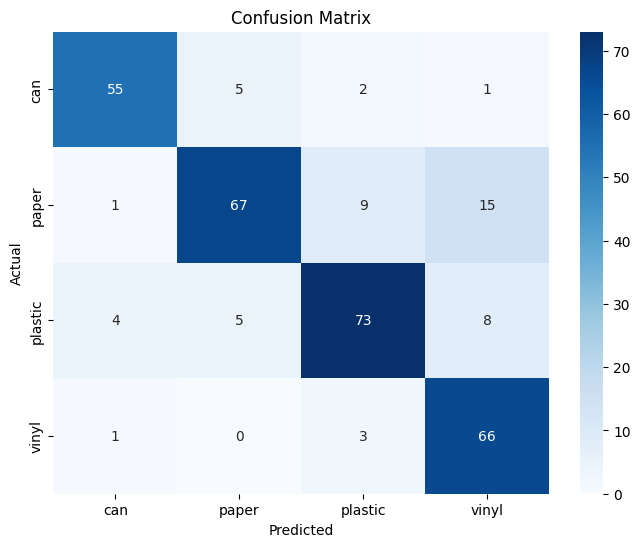

In [9]:
cm = confusion_matrix(y_true, y_pred)

print(cm)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()